# 🏠 Previsão de Preços de Imóveis — Palmas/TO

Regressão supervisionada sobre um dataset **coletado por scraping próprio** (Chaves na Mão).
Pipeline: limpeza → EDA → feature engineering → modelagem → avaliação.

> Os dados brutos são gerados por `src/scraper.py`. Veja o README para a coleta.

## 1. Setup e carga dos dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
IMG = "../images"

import glob, os
arq = max(glob.glob("../data/raw/imoveis_venda_*.csv"), key=os.path.getmtime)  # CSV mais recente
df = pd.read_csv(arq)
print("Fonte:", os.path.basename(arq))
print(df.shape)
df.head()

Fonte: imoveis_venda_palmas_20260616.csv
(1093, 15)


,id,operacao,tipo,preco,area_util,area_total,quartos,banheiros,vagas,salas,rua,bairro,cidade,uf,url
0,41871752,venda,sala comercial,350000.0,41.0,41.0,NaN,NaN,NaN,NaN,Quadra 201 Sul Avenida Joaquim Teotônio Segurado,Plano Diretor Sul,Palmas,TO,https://www.chavesnamao.com.br/imovel/sala-com...
1,16922339,venda,fazenda,40640000.0,500.0,12293600.0,NaN,NaN,NaN,3.0,"Avenida Joaquim Teotônio Segurado, 500",Plano Diretor Sul,Palmas,TO,https://www.chavesnamao.com.br/imovel/fazenda-...
2,43207187,venda,casa,690000.0,120.0,220.0,3.0,3.0,2.0,NaN,Quadra Arso 151 Qi 33,Plano Diretor Sul,Palmas,TO,https://www.chavesnamao.com.br/imovel/casa-a-v...
3,28592873,venda,fazenda,29700000.0,250.0,5928000.0,NaN,2.0,1.0,NaN,"Avenida Goiás, 122",Área Rural de Palmas,Palmas,TO,https://www.chavesnamao.com.br/imovel/fazenda-...
4,43033432,venda,sala comercial,253200.0,324.0,300.0,NaN,NaN,NaN,NaN,"Quadra 603 Norte Alameda 11, 05",Plano Diretor Norte,Palmas,TO,https://www.chavesnamao.com.br/imovel/sala-com...


## 2. Limpeza

Decisões de limpeza:
- Manter apenas **imóveis residenciais** (o alvo é preço de moradia).
- Remover anúncios **sem preço** ("sob consulta") — não dá pra treinar nem avaliar.
- `vagas` ausente é interpretado como **0 vagas**.
- Remover **outliers implausíveis** de preço, área e preço/m² (erros de digitação no anúncio).

In [2]:
residenciais = ["casa", "apartamento", "cobertura", "flat", "casa em condominio", "sobrado"]
df = df[df["tipo"].isin(residenciais)].copy()

antes = len(df)
df = df.dropna(subset=["preco", "area_util", "quartos"])
df["vagas"] = df["vagas"].fillna(0)
df["banheiros"] = df["banheiros"].fillna(df["banheiros"].median())

df = df[(df["preco"] >= 50_000) & (df["preco"] <= 10_000_000)]
df = df[(df["area_util"] >= 20) & (df["area_util"] <= 2_000)]
df["preco_m2"] = df["preco"] / df["area_util"]
df = df[(df["preco_m2"] >= 500) & (df["preco_m2"] <= 30_000)]

print(f"{antes} -> {len(df)} imóveis após limpeza")
df[["preco", "area_util", "quartos", "banheiros", "vagas", "preco_m2"]].describe().round(0)

967 -> 938 imóveis após limpeza


,preco,area_util,quartos,banheiros,vagas,preco_m2
count,938.0,938.0,938.0,938.0,938.0,938.0
mean,1290306.0,172.0,3.0,3.0,2.0,7219.0
std,1246756.0,131.0,1.0,1.0,1.0,3417.0
min,120000.0,31.0,1.0,1.0,0.0,505.0
25%,539250.0,94.0,3.0,2.0,2.0,4888.0
50%,838500.0,138.0,3.0,3.0,2.0,6364.0
75%,1472500.0,213.0,3.0,4.0,3.0,8555.0
max,8000000.0,1917.0,12.0,12.0,12.0,24710.0


## 3. Análise Exploratória (EDA)

### 3.1 Distribuição do preço — por que usar escala log

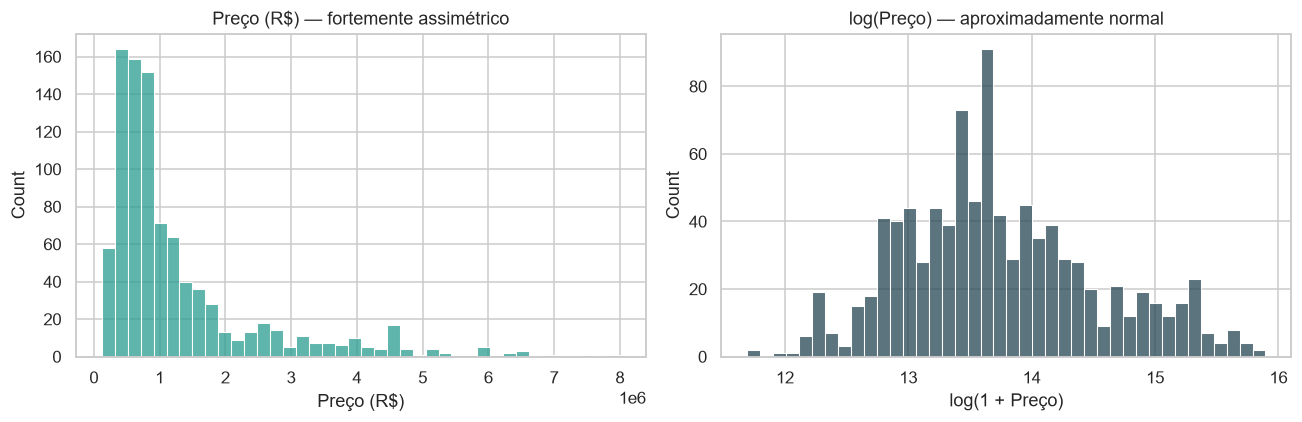

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["preco"], bins=40, ax=ax[0], color="#2A9D8F")
ax[0].set_title("Preço (R$) — fortemente assimétrico")
ax[0].set_xlabel("Preço (R$)")
sns.histplot(np.log1p(df["preco"]), bins=40, ax=ax[1], color="#264653")
ax[1].set_title("log(Preço) — aproximadamente normal")
ax[1].set_xlabel("log(1 + Preço)")
plt.tight_layout(); plt.savefig(f"{IMG}/dist_preco.png", bbox_inches="tight"); plt.show()

> O preço é fortemente assimétrico à direita (poucos imóveis muito caros). A transformação
> `log` aproxima a distribuição da normal — por isso o **alvo do modelo será `log(preço)`**,
> o que estabiliza a variância e reduz o peso dos imóveis de altíssimo valor.

### 3.2 Preço por m² por bairro

C:\Users\augus\AppData\Local\Temp\ipykernel_22920\1712275919.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["bairro"].isin(top)], x="preco_m2", y="bairro",


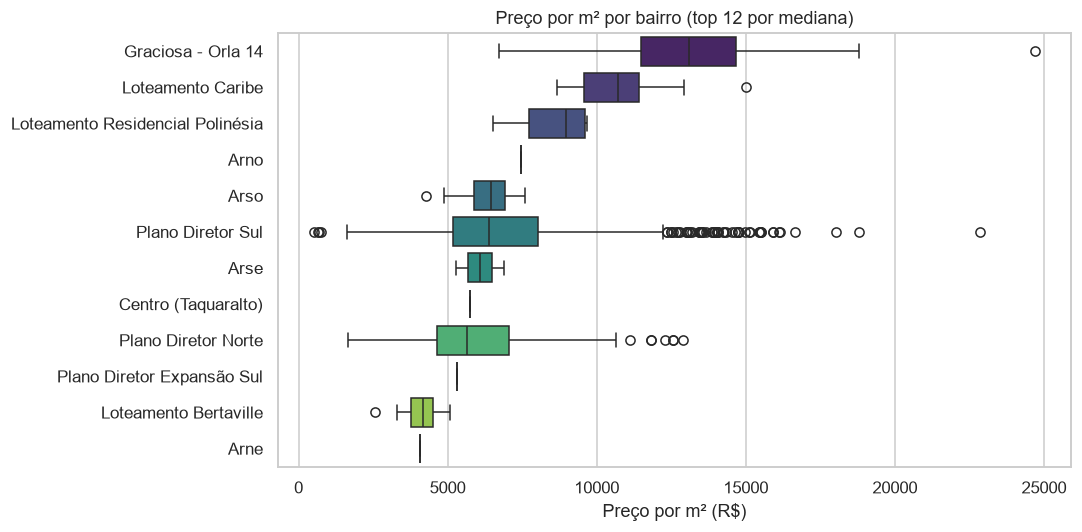

In [4]:
ordem = df.groupby("bairro")["preco_m2"].median().sort_values(ascending=False)
top = ordem.head(12).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["bairro"].isin(top)], x="preco_m2", y="bairro",
            order=top, palette="viridis")
plt.title("Preço por m² por bairro (top 12 por mediana)")
plt.xlabel("Preço por m² (R$)"); plt.ylabel("")
plt.tight_layout(); plt.savefig(f"{IMG}/preco_m2_bairro.png", bbox_inches="tight"); plt.show()

> Localização é determinante: a mediana de preço/m² varia bastante entre bairros — informação que o modelo precisa capturar via o bairro como variável categórica.

### 3.3 Correlações entre atributos numéricos e o preço

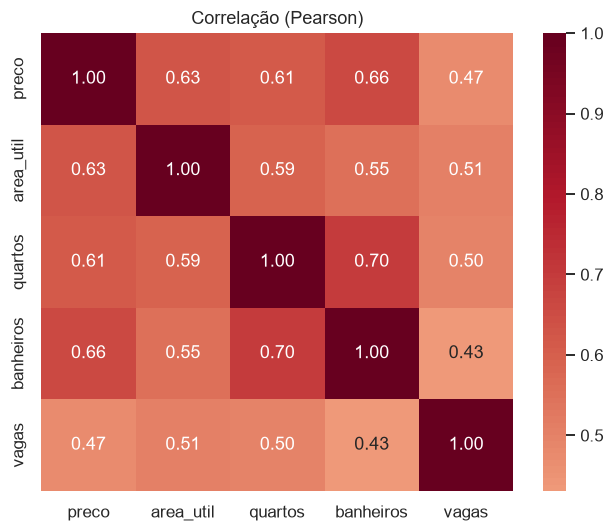

In [5]:
num_cols = ["preco", "area_util", "quartos", "banheiros", "vagas"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlação (Pearson)")
plt.tight_layout(); plt.savefig(f"{IMG}/correlacao.png", bbox_inches="tight"); plt.show()

> A **área útil** é o atributo numérico mais correlacionado com o preço, seguida por banheiros e vagas — coerente com a intuição do mercado imobiliário.

## 4. Feature engineering e split

- **Alvo:** `log(1 + preço)`.
- **Numéricas:** área útil, quartos, banheiros, vagas (padronizadas).
- **Categóricas:** tipo e bairro (one-hot). Bairros com < 10 imóveis viram `"Outros"` para evitar categorias raras que causam overfitting.

In [6]:
freq = df["bairro"].value_counts()
raros = freq[freq < 10].index
df["bairro_grp"] = df["bairro"].where(~df["bairro"].isin(raros), "Outros")

num = ["area_util", "quartos", "banheiros", "vagas"]
cat = ["tipo", "bairro_grp"]
X = df[num + cat]
y = np.log1p(df["preco"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pre = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])
print("Treino:", X_train.shape, "| Teste:", X_test.shape, "| Bairros:", df["bairro_grp"].nunique())

Treino: (750, 6) | Teste: (188, 6) | Bairros: 8


## 5. Modelagem e avaliação

Treinamos do modelo mais simples (Regressão Linear) aos baseados em árvore. As métricas em
**R$** vêm da previsão revertida para a escala original (`expm1`); reportamos também o **R² em
escala log**, que é a comparação justa entre os modelos.

In [7]:
def avaliar(nome, modelo):
    pipe = Pipeline([("pre", pre), ("model", modelo)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log); real = np.expm1(y_test)
    return {
        "Modelo": nome,
        "MAE (R$)": mean_absolute_error(real, pred),
        "RMSE (R$)": np.sqrt(mean_squared_error(real, pred)),
        "R² (R$)": r2_score(real, pred),
        "R² (log)": r2_score(y_test, pred_log),
    }, pipe

modelos = {
    "Regressão Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}
resultados, pipes = [], {}
for nome, m in modelos.items():
    res, pipe = avaliar(nome, m); resultados.append(res); pipes[nome] = pipe

tab = pd.DataFrame(resultados).set_index("Modelo")
tab.round({"MAE (R$)": 0, "RMSE (R$)": 0, "R² (R$)": 3, "R² (log)": 3})

,MAE (R$),RMSE (R$),R² (R$),R² (log)
Modelo,,,,
Regressão Linear,702211.0,3279942.0,-6.896,0.709
Ridge,698280.0,3296159.0,-6.974,0.710
Lasso,694819.0,3300121.0,-6.993,0.710
Random Forest,267336.0,546362.0,0.781,0.852
Gradient Boosting,276710.0,514601.0,0.806,0.857


> **Leitura dos resultados:** em escala **log** os modelos lineares são competitivos
> (R² ≈ 0,71). Mas, ao reverter para reais, uma única previsão extrapolada explode
> exponencialmente (`expm1`), derrubando o R² em R$ — um efeito clássico de regressão linear
> em alvo log. Os modelos **baseados em árvore não extrapolam** e por isso são muito mais
> robustos aqui, com **R² ≈ 0,80 em reais**. Para produção, o **Gradient Boosting** é a escolha.

### 5.1 Validação cruzada do modelo vencedor

In [8]:
melhor = pipes["Gradient Boosting"]
scores = cross_val_score(melhor, X, y, cv=5, scoring="r2")
print(f"R² (log) em 5-fold CV: {scores.mean():.3f} ± {scores.std():.3f}")

R² (log) em 5-fold CV: 0.834 ± 0.029


### 5.2 Importância das features

C:\Users\augus\AppData\Local\Temp\ipykernel_22920\3071021936.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette="viridis")


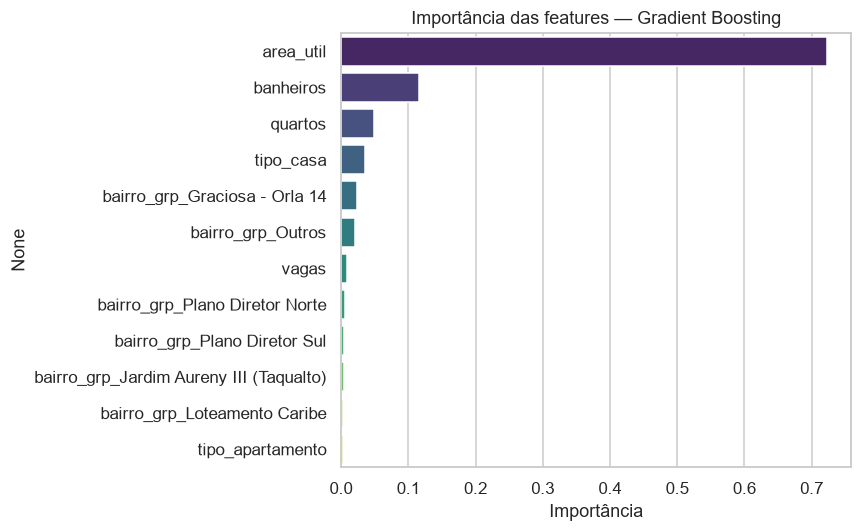

area_util                                  0.723001
banheiros                                  0.115563
quartos                                    0.049084
tipo_casa                                  0.036190
bairro_grp_Graciosa - Orla 14              0.023696
bairro_grp_Outros                          0.020370
vagas                                      0.008327
bairro_grp_Plano Diretor Norte             0.005705
bairro_grp_Plano Diretor Sul               0.004961
bairro_grp_Jardim Aureny III (Taqualto)    0.004076
bairro_grp_Loteamento Caribe               0.003169
tipo_apartamento                           0.003155
dtype: float64

In [9]:
gb = pipes["Gradient Boosting"]
ohe = gb.named_steps["pre"].named_transformers_["cat"]
nomes = num + list(ohe.get_feature_names_out(cat))
imp = pd.Series(gb.named_steps["model"].feature_importances_, index=nomes).sort_values(ascending=False).head(12)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, palette="viridis")
plt.title("Importância das features — Gradient Boosting")
plt.xlabel("Importância"); plt.tight_layout()
plt.savefig(f"{IMG}/importancia_features.png", bbox_inches="tight"); plt.show()
imp

### 5.3 Previsto vs. Real

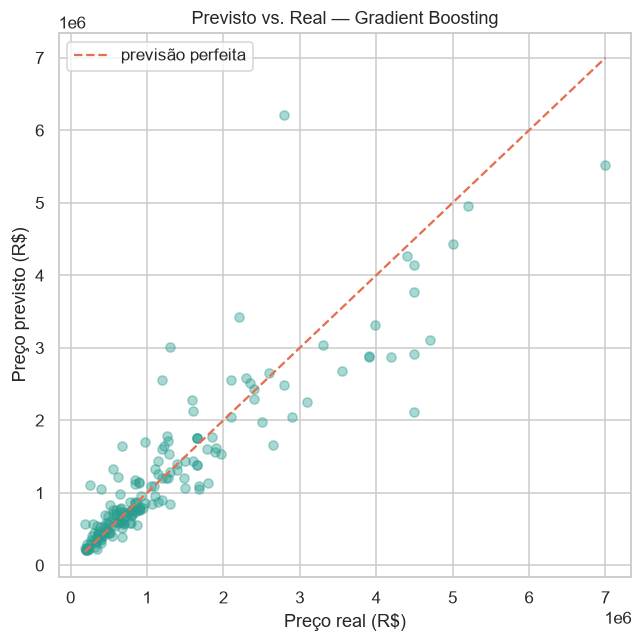

In [10]:
pred = np.expm1(melhor.predict(X_test)); real = np.expm1(y_test)
plt.figure(figsize=(6, 6))
plt.scatter(real, pred, alpha=0.4, color="#2A9D8F")
lim = [real.min(), real.max()]
plt.plot(lim, lim, "--", color="#E76F51", label="previsão perfeita")
plt.xlabel("Preço real (R$)"); plt.ylabel("Preço previsto (R$)")
plt.title("Previsto vs. Real — Gradient Boosting")
plt.legend(); plt.tight_layout()
plt.savefig(f"{IMG}/previsto_vs_real.png", bbox_inches="tight"); plt.show()

## 6. Conclusões

- **Área útil e localização (bairro)** são os principais determinantes do preço — coerente com o mercado.
- O **Gradient Boosting** prevê o preço com **R² ≈ 0,80** e **MAE ≈ R$ 277 mil** (mediana de preço ~R$ 840 mil).
- O erro residual reflete o limite dos atributos públicos do anúncio: não há estado de conservação,
  acabamento, andar, idade do imóvel nem localização exata — variáveis que explicariam parte do que sobra.
- **Lição metodológica:** avaliar no espaço certo importa. Modelos lineares pareciam ruins em R$ por causa de
  uma extrapolação isolada, mas eram razoáveis em log; modelos de árvore são naturalmente robustos a isso.

### Próximas etapas
- [ ] Coletar mais cidades para generalizar além de Palmas
- [ ] Enriquecer com features de texto do anúncio (descrição) e geolocalização
- [ ] Tunar hiperparâmetros (GridSearch) e testar XGBoost/LightGBM
- [ ] Servir o modelo como API (FastAPI) — integrando com o restante do portfólio